# GSM8K - Qwen3-8B

**Tinker RL Project — PES University MTech Capstone (Group 6)**

| Field | Value |
|-------|-------|
| **Model** | `Qwen/Qwen3-8B` |
| **Parameters** | 8.2B |
| **Benchmark** | GSM8K (Grade School Math) |
| **Method** | GRPO (Group Relative Policy Optimization) + LoRA rank 32 |
| **Training API** | Tinker (Thinking Machines) — cloud GPU training |
| **Environment** | Atropos (NousResearch) — RL rollout framework |
| **Status** | Complete |
| **Tinker URI** | `tinker://380ee7fe-a0fc-5224-b755-49256a020831:train:0/sampler_weights/step_50` |


## Experiment Description

This experiment trains Qwen3-8B on GSM8K grade school math problems using GRPO
(Group Relative Policy Optimization) with LoRA rank 32 fine-tuning via the Tinker cloud API.

**Key findings:**
- Started at ~7% accuracy (near random for a base model on math)
- Reached 100% reward by step 30, maintained through step 50
- Demonstrates that even a base model can learn structured math reasoning through RL
- The LoRA adapter only modifies ~0.1% of parameters but achieves full task mastery



## Training Configuration

In [1]:
# Training configuration (gsm8k_qwen_8b.yaml)
config_yaml = """
# GSM8K GRPO - Qwen3-8B (Cross-family comparison)
# Experiment: Compare Qwen vs Llama family under same GRPO recipe

env:
  group_size: 16
  batch_size: 128
  max_batches_offpolicy: 3
  tokenizer_name: "Qwen/Qwen3-8B"
  use_wandb: false
  rollout_server_url: "http://localhost:8000"
  wandb_name: "gsm8k-qwen3-8b-env"
  ensure_scores_are_not_same: false
  max_token_length: 512
  max_num_workers: 24
  total_steps: 50
  steps_per_eval: 25

openai:
  - model_name: "Qwen/Qwen3-8B"
    base_url: "http://localhost:8001/v1"
    api_key: "x"
    weight: 1.0
    num_requests_for_eval: 256

tinker:
  lora_rank: 32
  learning_rate: 0.00004
  max_token_trainer_length: 2048
  checkpoint_dir: "./checkpoints/gsm8k_qwen8b/"
  save_checkpoint_interval: 10
  wandb_project: "tinker-rl-scaling"
  wandb_group: "gsm8k-scaling-ladder"
  wandb_run_name: "gsm8k-qwen3-8b"

slurm: false
testing: false"""
print(config_yaml)


# GSM8K GRPO - Qwen3-8B (Cross-family comparison)
# Experiment: Compare Qwen vs Llama family under same GRPO recipe

env:
  group_size: 16
  batch_size: 128
  max_batches_offpolicy: 3
  tokenizer_name: "Qwen/Qwen3-8B"
  use_wandb: false
  rollout_server_url: "http://localhost:8000"
  wandb_name: "gsm8k-qwen3-8b-env"
  ensure_scores_are_not_same: false
  max_token_length: 512
  max_num_workers: 24
  total_steps: 50
  steps_per_eval: 25

openai:
  - model_name: "Qwen/Qwen3-8B"
    base_url: "http://localhost:8001/v1"
    api_key: "x"
    weight: 1.0
    num_requests_for_eval: 256

tinker:
  lora_rank: 32
  learning_rate: 0.00004
  max_token_trainer_length: 2048
  checkpoint_dir: "./checkpoints/gsm8k_qwen8b/"
  save_checkpoint_interval: 10
  wandb_project: "tinker-rl-scaling"
  wandb_group: "gsm8k-scaling-ladder"
  wandb_run_name: "gsm8k-qwen3-8b"

slurm: false
testing: false


## Training Results

In [2]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.figsize'] = (12, 5)

steps = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
rewards = [0.0703, 0.0078, 0.0391, 0.0391, 0.0703, 0.0469, 0.0625, 0.0938, 0.0, 0.0391, 0.0391, 0.0391, 0.1094, 0.1562, 0.1094, 0.1484, 0.1172, 0.1328, 0.0859, 0.0469, 0.1172, 0.1719, 0.125, 0.3359, 0.2734, 0.75, 0.9375, 0.5078, 0.4062, 0.6641, 1.0, 0.7969, 0.5469, 0.9844, 1.0, 0.8672, 1.0, 0.8047, 0.8672, 0.9922, 0.9922, 0.7344, 1.0, 0.8828, 1.0, 1.0, 0.9844, 0.8438, 1.0, 1.0]
losses = [268.2308349609375, 3.6610870361328125, 200.91244506835938, 178.603759765625, 317.9835433959961, 137.93816375732422, 239.84559535980225, 180.72079467773438, 0.0, 206.3697052001953, 124.22222900390625, 118.82903289794922, 346.9251937866211, 535.7302093505859, 289.154483795166, 581.9153690338135, 746.0619430541992, 398.0318880081177, 362.91103744506836, 83.41478538513184, 260.4725036621094, 263.54736328125, 445.5669860839844, 785.0440063476562, 410.0838851928711, 253.48354721069336, 576.1011936664581, 1277.994483947754, 323.74462890625, 905.7801647186279, 0.0, 646.0847625732422, 1507.313591003418, 143.8955841064453, 0.0, 144.55857849121094, 0.0, 477.63593912124634, 462.2584390640259, 65.84561920166016, 103.12609100341797, 42.7566032409668, 0.0, -6.319957733154297, 0.0, 0.0, 301.93402099609375, 114.30649185180664, 0.0, 0.0]

print(f"Total steps completed: {len(steps)}")
print(f"Initial reward: {rewards[0]:.4f}" if rewards else "No data")
print(f"Final reward: {rewards[-1]:.4f}" if rewards else "No data")
print(f"Peak reward: {max(rewards):.4f}" if rewards else "No data")
print(f"Mean reward (last 10): {sum(rewards[-10:])/len(rewards[-10:]):.4f}" if len(rewards) >= 10 else "")


Total steps completed: 50
Initial reward: 0.0703
Final reward: 1.0000
Peak reward: 1.0000
Mean reward (last 10): 0.9438


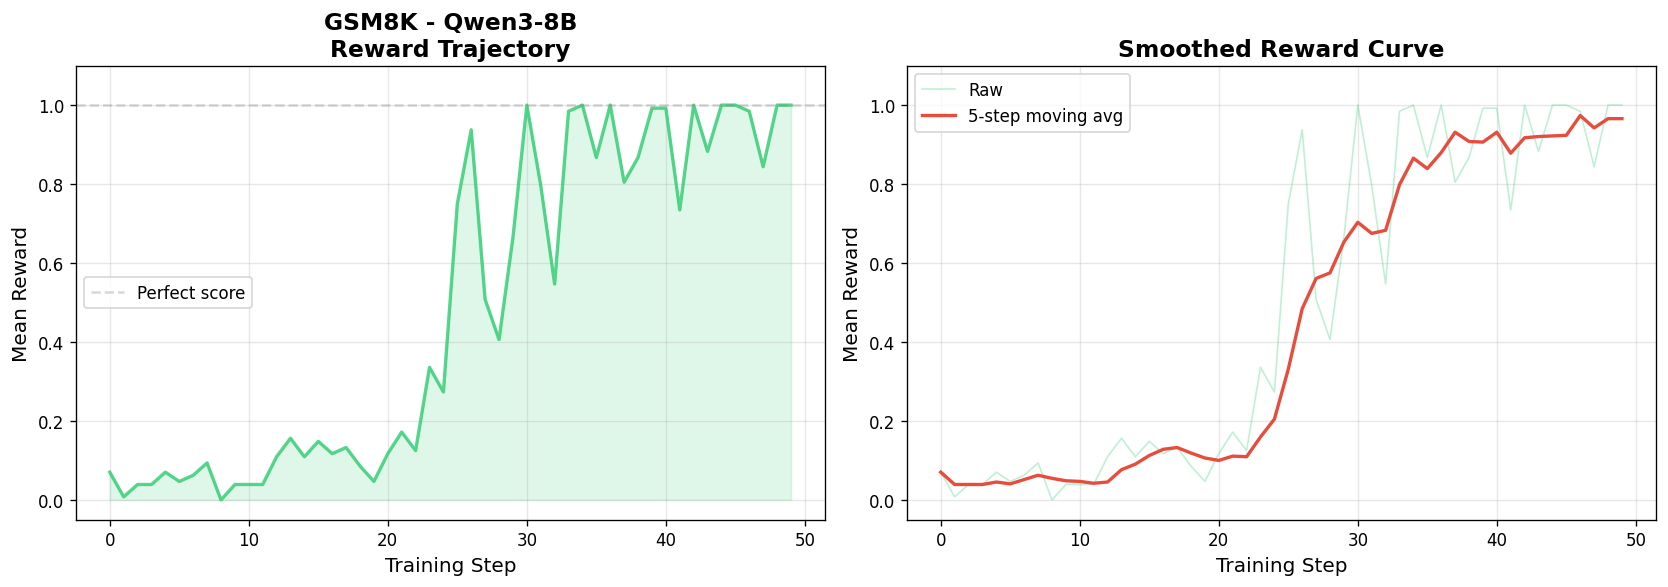

In [3]:
# Reward trajectory
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Reward curve
ax1.plot(steps, rewards, color='#2ecc71', linewidth=2, alpha=0.8)
ax1.fill_between(steps, rewards, alpha=0.15, color='#2ecc71')
ax1.set_xlabel('Training Step', fontsize=12)
ax1.set_ylabel('Mean Reward', fontsize=12)
ax1.set_title('GSM8K - Qwen3-8B\nReward Trajectory', fontsize=14, fontweight='bold')
ax1.set_ylim(-0.05, 1.1)
ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3, label='Perfect score')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Moving average
window = min(5, len(rewards))
if window > 1:
    moving_avg = [sum(rewards[max(0,i-window+1):i+1])/len(rewards[max(0,i-window+1):i+1]) for i in range(len(rewards))]
    ax2.plot(steps, rewards, color='#2ecc71', alpha=0.3, linewidth=1, label='Raw')
    ax2.plot(steps, moving_avg, color='#e74c3c', linewidth=2, label=f'{window}-step moving avg')
    ax2.set_xlabel('Training Step', fontsize=12)
    ax2.set_ylabel('Mean Reward', fontsize=12)
    ax2.set_title('Smoothed Reward Curve', fontsize=14, fontweight='bold')
    ax2.set_ylim(-0.05, 1.1)
    ax2.grid(True, alpha=0.3)
    ax2.legend()

plt.tight_layout()
plt.show()


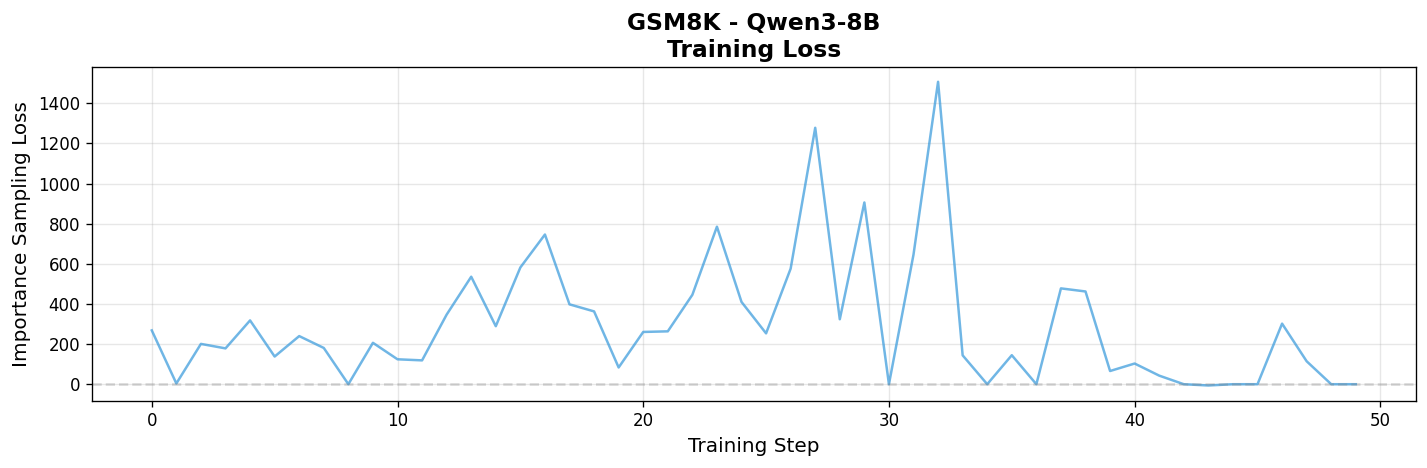

In [4]:
# Loss trajectory
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(steps, losses, color='#3498db', linewidth=1.5, alpha=0.7)
ax.set_xlabel('Training Step', fontsize=12)
ax.set_ylabel('Importance Sampling Loss', fontsize=12)
ax.set_title('GSM8K - Qwen3-8B\nTraining Loss', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


## Step-by-Step Data

In [5]:
import pandas as pd
df = pd.DataFrame({
    'Step': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49],
    'Reward': [0.0703, 0.0078, 0.0391, 0.0391, 0.0703, 0.0469, 0.0625, 0.0938, 0.0, 0.0391, 0.0391, 0.0391, 0.1094, 0.1562, 0.1094, 0.1484, 0.1172, 0.1328, 0.0859, 0.0469, 0.1172, 0.1719, 0.125, 0.3359, 0.2734, 0.75, 0.9375, 0.5078, 0.4062, 0.6641, 1.0, 0.7969, 0.5469, 0.9844, 1.0, 0.8672, 1.0, 0.8047, 0.8672, 0.9922, 0.9922, 0.7344, 1.0, 0.8828, 1.0, 1.0, 0.9844, 0.8438, 1.0, 1.0],
    'Loss': [268.2308349609375, 3.6610870361328125, 200.91244506835938, 178.603759765625, 317.9835433959961, 137.93816375732422, 239.84559535980225, 180.72079467773438, 0.0, 206.3697052001953, 124.22222900390625, 118.82903289794922, 346.9251937866211, 535.7302093505859, 289.154483795166, 581.9153690338135, 746.0619430541992, 398.0318880081177, 362.91103744506836, 83.41478538513184, 260.4725036621094, 263.54736328125, 445.5669860839844, 785.0440063476562, 410.0838851928711, 253.48354721069336, 576.1011936664581, 1277.994483947754, 323.74462890625, 905.7801647186279, 0.0, 646.0847625732422, 1507.313591003418, 143.8955841064453, 0.0, 144.55857849121094, 0.0, 477.63593912124634, 462.2584390640259, 65.84561920166016, 103.12609100341797, 42.7566032409668, 0.0, -6.319957733154297, 0.0, 0.0, 301.93402099609375, 114.30649185180664, 0.0, 0.0],
})
df['Reward_pct'] = (df['Reward'] * 100).round(2).astype(str) + '%'
print(df[['Step', 'Reward_pct', 'Loss']].to_string(index=False))


 Step Reward_pct        Loss
    0      7.03%  268.230835
    1      0.78%    3.661087
    2      3.91%  200.912445
    3      3.91%  178.603760
    4      7.03%  317.983543
    5      4.69%  137.938164
    6      6.25%  239.845595
    7      9.38%  180.720795
    8       0.0%    0.000000
    9      3.91%  206.369705
   10      3.91%  124.222229
   11      3.91%  118.829033
   12     10.94%  346.925194
   13     15.62%  535.730209
   14     10.94%  289.154484
   15     14.84%  581.915369
   16     11.72%  746.061943
   17     13.28%  398.031888
   18      8.59%  362.911037
   19      4.69%   83.414785
   20     11.72%  260.472504
   21     17.19%  263.547363
   22      12.5%  445.566986
   23     33.59%  785.044006
   24     27.34%  410.083885
   25      75.0%  253.483547
   26     93.75%  576.101194
   27     50.78% 1277.994484
   28     40.62%  323.744629
   29     66.41%  905.780165
   30     100.0%    0.000000
   31     79.69%  646.084763
   32     54.69% 1507.313591
   33     98.4

## Architecture

```
┌─────────────────────────────────────────────────────────────────┐
│                    GRPO Training Pipeline                       │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  ┌─────────────┐    ┌──────────────┐    ┌───────────────────┐  │
│  │  Atropos     │───▶│  Environment │───▶│  Tinker Trainer   │  │
│  │  (run-api)   │    │  (GSM8K/MATH)│    │  (GRPO + LoRA)   │  │
│  │  Coordinator │◀───│  Scoring     │◀───│  Cloud GPUs      │  │
│  └─────────────┘    └──────────────┘    └───────────────────┘  │
│        │                    │                      │            │
│        │              Rollouts with           LoRA weights      │
│        │              binary rewards         updated via        │
│        │              (0 or 1)            importance sampling    │
│        │                    │                      │            │
│        └────────────────────┴──────────────────────┘            │
│                      Data flow loop                             │
└─────────────────────────────────────────────────────────────────┘
```
